
<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_01_pinguinos_v2_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




LABORATORIO — Observatorio de Datos (Pingüinos)

Objetivo
Guiar para la exploración, descripción, formulación de hipótesis y pruebas básicas usando el dataset de pingüinos, hasta generar un reporte reproducible. El laboratorio se divide en dos fases: (1) enfoque clásico con notebook y (2) enfoque con agentes.

Requisitos
- Python 3.x
- pandas, numpy, matplotlib, seaborn (opcional)
- scipy (opcional, para pruebas)

FASE 1 — Enfoque clásico (hasta Parte F)

Nota: el estudiante debe construir su propio runner (script en Python) para ejecutar operaciones y guardar artifacts.

Parte A — Observación inicial
1) ¿Cuántas filas y columnas tiene el dataset?
2) ¿Qué variables son numéricas y cuáles categóricas?
3) ¿Cuántos valores faltantes hay por columna?
4) ¿Existen filas duplicadas?
5) ¿Qué variables tienen baja cardinalidad?

Parte B — Descripción
6) Para cada variable numérica, reporte media, mediana, desviación estándar y rango intercuartílico.
7) Para cada variable categórica, reporte conteos y porcentajes.
8) Construya tablas cruzadas para pares de variables categóricas relevantes.
9) Calcule matrices de correlación (Pearson y Spearman) entre variables numéricas.

Parte C — Visualización
10) Genere gráficos de conteo para todas las variables categóricas de baja cardinalidad.
11) Genere histogramas para variables numéricas y describa su forma.
12) Genere boxplots de una variable numérica por categoría (p. ej., `bill_length_mm` por `species`).
13) Genere un scatter entre dos variables numéricas y coloree por una categoría.
14) Genere un heatmap de correlación.

Parte D — Hipótesis (sin causalidad)
15) Proponga al menos 3 hipótesis falsables basadas en los gráficos y descriptivos.
   Ejemplos:
   - `flipper_length_mm` se asocia con `body_mass_g`.
   - `bill_length_mm` difiere por `species`.
   - `species` se asocia con `island`.

Parte E — Pruebas estadísticas
16) Seleccione una prueba adecuada para cada hipótesis (Pearson/Spearman, ANOVA/Kruskal, chi-cuadrado).
17) Reporte estadístico y p-valor.
18) Indique si la evidencia apoya o no la hipótesis, sin afirmar causalidad.

Parte F — Conclusiones y reporte
19) Redacte conclusiones en tres capas:
    A) Hallazgos descriptivos (con evidencia).
    B) Patrones visuales (con evidencia).
    C) Próximas hipótesis a probar.
20) Incluya preguntas para un investigador humano (p. ej., manejo de la variable `sex`, control por `species`).

# Fase 1: Pre-analisis de estudiante

Todo mi análisis del procesamiento de datos se encuentra en la fase 2, en donde cambié un poco el prompt del agente y el runner para que se centrara en que yo debo hacer el análisis de datos a partir de los artefactos. El agente me propone preguntas críticas en cada "subfase" que yo respondo en el archivo "student_log.md"

In [49]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association

In [50]:
# Con este análisis, respondo ambas la fase 1 y la fase 0 de la fase 2 usando agentes. 
# Para responder la pregunta socrática 1, exploremos el dataset:
df_raw = sns.load_dataset("penguins")
df_raw.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### Parte A

In [51]:
#1) ¿Cuántas filas y columnas tiene el dataset?
print(df_raw.columns, "\n================================")
df_raw.shape

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='str') 


(344, 7)

In [52]:
# 2) ¿Qué variables son numéricas y cuáles categóricas?

print("VARIABLES NUMÉRICAS: \n",df_raw.describe(include=[np.number],exclude=['str',object]),"\n ================================")

print("VARIABLES CATEGÓRICAS: \n",df_raw.describe(include=object))

VARIABLES NUMÉRICAS: 
        bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000      13.100000         172.000000  2700.000000
25%         39.225000      15.600000         190.000000  3550.000000
50%         44.450000      17.300000         197.000000  4050.000000
75%         48.500000      18.700000         213.000000  4750.000000
max         59.600000      21.500000         231.000000  6300.000000 
VARIABLES CATEGÓRICAS: 
        species  island   sex
count      344     344   333
unique       3       3     2
top     Adelie  Biscoe  Male
freq       152     168   168


/tmp/ipykernel_98728/2630479383.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("VARIABLES CATEGÓRICAS: \n",df_raw.describe(include=object))


In [53]:
# 3) ¿Cuántos valores faltantes hay por columna?
print(df_raw.info(), "\n================================")


<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB
None 


In [54]:
# 4) ¿Existen filas duplicadas?
df_raw.duplicated().sum()

np.int64(0)

In [55]:
# 5) ¿Qué variables tienen baja cardinalidad?
for col in df_raw.columns:
    unique_values = df_raw[col].nunique()
    no_nulos = df_raw[col].notnull().sum()
    proporcion = unique_values / no_nulos if no_nulos > 0 else 0
    print(f"Columna: {col}, Valores únicos: {unique_values}, proporcion: {proporcion*100:.2f}%")


"""
 Yo consideraria variables con baja cardinanalidad las que tienen una proporcion
 aquellas que tienen una proporcion de datos únicos menor al 5% respecto el total de datos no nulos.

 En este caso: species, island y sex. Esto tiene sentido pues son las 3 variables categóricas,
 mientras que las otras son numéricas continuas.
 
 """

Columna: species, Valores únicos: 3, proporcion: 0.87%
Columna: island, Valores únicos: 3, proporcion: 0.87%
Columna: bill_length_mm, Valores únicos: 164, proporcion: 47.95%
Columna: bill_depth_mm, Valores únicos: 80, proporcion: 23.39%
Columna: flipper_length_mm, Valores únicos: 55, proporcion: 16.08%
Columna: body_mass_g, Valores únicos: 94, proporcion: 27.49%
Columna: sex, Valores únicos: 2, proporcion: 0.60%


'\n Yo consideraria variables con baja cardinanalidad las que tienen una proporcion\n aquellas que tienen una proporcion de datos únicos menor al 5% respecto el total de datos no nulos.\n\n En este caso: species, island y sex. Esto tiene sentido pues son las 3 variables categóricas,\n mientras que las otras son numéricas continuas.\n\n '

### Parte B

In [56]:
# 6) Para cada variable numérica, reporte media, mediana, desviación estándar y rango intercuartílico.
print("REPORTE VARIABLES NUMÉRICAS: \n",df_raw.describe(include=[np.number],exclude=['str',object]),"\n ================================")

REPORTE VARIABLES NUMÉRICAS: 
        bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000      13.100000         172.000000  2700.000000
25%         39.225000      15.600000         190.000000  3550.000000
50%         44.450000      17.300000         197.000000  4050.000000
75%         48.500000      18.700000         213.000000  4750.000000
max         59.600000      21.500000         231.000000  6300.000000 


Tabla de Contingencia Species e Island:
island     Biscoe  Dream  Torgersen
species                            
Adelie         44     56         52
Chinstrap       0     68          0
Gentoo        124      0          0


Tabla de Contingencia Species y Sex:
sex        Female  Male
species                
Adelie         73    73
Chinstrap      34    34
Gentoo         58    61


ANÁLISIS DE LA TABLA DE CONTINGENCIA ENTRE ESPECIES E ISLAND:
Chi-cuadrado: 299.5503
P-valor: 0.0000
Significativo: Sí


V de Cramér: 0.6598




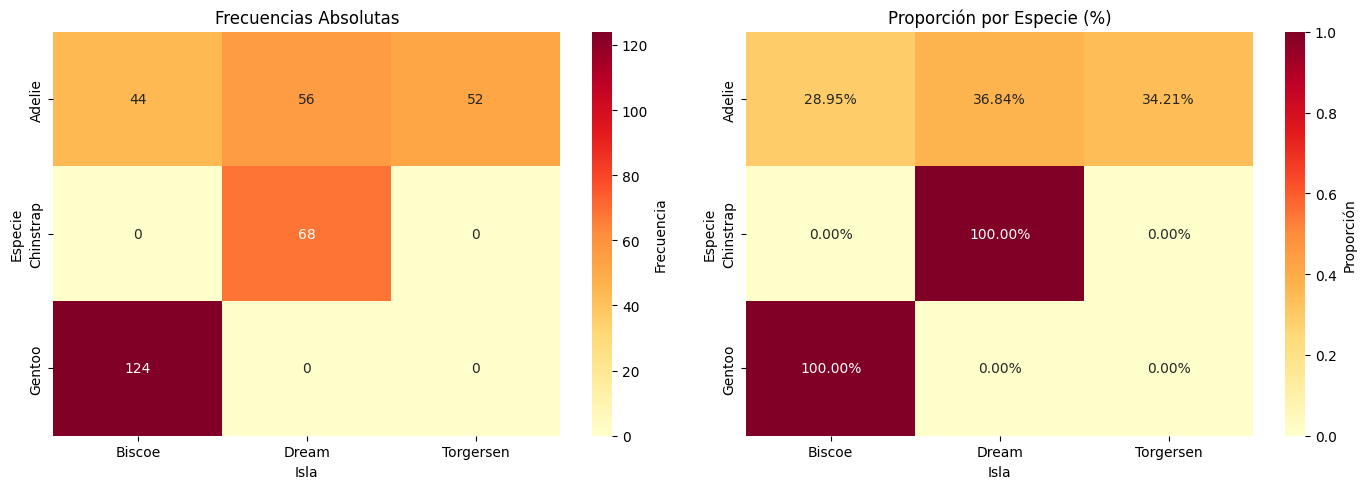

In [57]:
# 7) Para cada variable categórica, reporte conteos y porcentajes.
# 8) Construya tablas cruzadas para pares de variables categóricas relevantes.

# Aquí si voy a usar el agente de IA para generar una crosstab:

# Claude:
# Asumiendo que tienes un DataFrame 'df' con columnas 'species' e 'island'
df = df_raw
# 1.a TABLA DE CONTINGENCIA
contingency_table_a = pd.crosstab(df['species'], df['island'])
print("Tabla de Contingencia Species e Island:")
print(contingency_table_a)
print("\n")

# 1.b Esta si la propuse yo: TABLA DE CONTINGENCIA Species y Sex
contingency_table_b = pd.crosstab(df['species'], df['sex'])
print("Tabla de Contingencia Species y Sex:")
print(contingency_table_b)
print("\n")

print("ANÁLISIS DE LA TABLA DE CONTINGENCIA ENTRE ESPECIES E ISLAND:")
# 2. CHI-CUADRADO
chi2, p_value, dof, expected = chi2_contingency(contingency_table_a)
print(f"Chi-cuadrado: {chi2:.4f}")
print(f"P-valor: {p_value:.4f}")
print(f"Significativo: {'Sí' if p_value < 0.05 else 'No'}")
print("\n")

# 3. V DE CRAMÉR (correlación 0-1)
n = contingency_table_a.sum().sum()
cramer_v = np.sqrt(chi2 / (n * (min(contingency_table_a.shape) - 1)))
print(f"V de Cramér: {cramer_v:.4f}")
print("\n")

# 4. VISUALIZACIÓN: HEATMAP
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap de frecuencias absolutas
sns.heatmap(contingency_table_a, annot=True, fmt='d', cmap='YlOrRd', 
            ax=axes[0], cbar_kws={'label': 'Frecuencia'})
axes[0].set_title('Frecuencias Absolutas')
axes[0].set_ylabel('Especie')
axes[0].set_xlabel('Isla')

# Heatmap de proporciones (normalizado por fila)
contingency_prop = contingency_table_a.div(contingency_table_a.sum(axis=1), axis=0)
sns.heatmap(contingency_prop, annot=True, fmt='.2%', cmap='YlOrRd', 
            ax=axes[1], cbar_kws={'label': 'Proporción'})
axes[1].set_title('Proporción por Especie (%)')
axes[1].set_ylabel('Especie')
axes[1].set_xlabel('Isla')

plt.tight_layout()
plt.show()

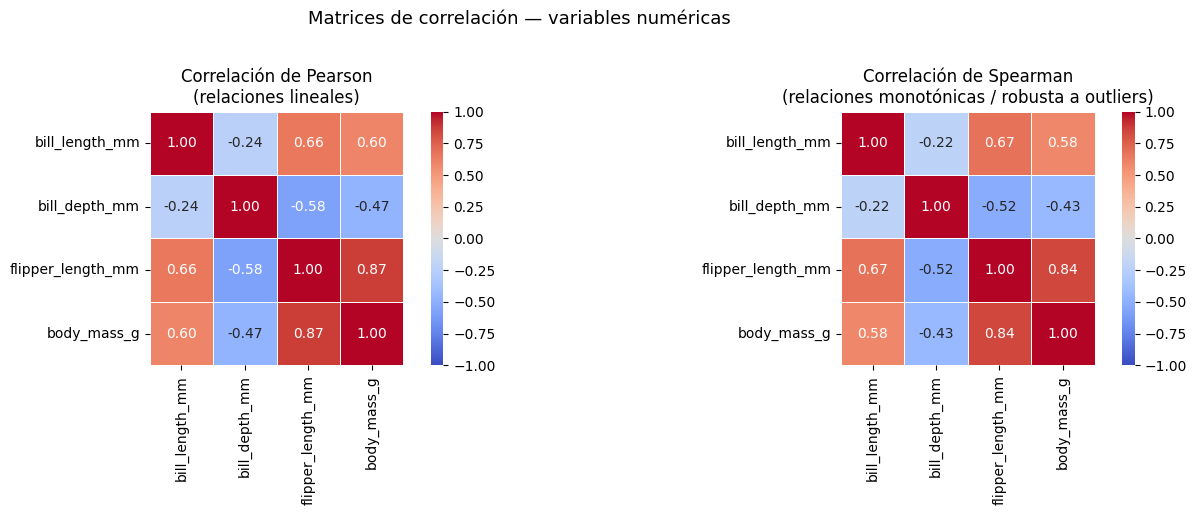

Diferencia absoluta Pearson − Spearman (pares con mayor divergencia):
            var_1             var_2  diff_abs
    bill_depth_mm flipper_length_mm  0.060584
    bill_depth_mm       body_mass_g  0.039543
flipper_length_mm       body_mass_g  0.031228
   bill_length_mm flipper_length_mm  0.016591
   bill_length_mm     bill_depth_mm  0.013304
   bill_length_mm       body_mass_g  0.011310
   bill_length_mm    bill_length_mm       NaN
    bill_depth_mm    bill_length_mm       NaN
    bill_depth_mm     bill_depth_mm       NaN
flipper_length_mm    bill_length_mm       NaN
flipper_length_mm     bill_depth_mm       NaN
flipper_length_mm flipper_length_mm       NaN
      body_mass_g    bill_length_mm       NaN
      body_mass_g     bill_depth_mm       NaN
      body_mass_g flipper_length_mm       NaN
      body_mass_g       body_mass_g       NaN


In [58]:
# 9) Calcule matrices de correlación (Pearson y Spearman) entre variables numéricas:
# Aqui también voy a usar el agente de IA para generar el código:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
df_num = df[numeric_cols]

corr_pearson  = df_num.corr(method="pearson")
corr_spearman = df_num.corr(method="spearman")

# ── Visualización ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

heatmap_kwargs = dict(annot=True, fmt=".2f", cmap="coolwarm",
                      center=0, square=True, linewidths=0.5,
                      vmin=-1, vmax=1)

sns.heatmap(corr_pearson,  ax=axes[0], **heatmap_kwargs)
axes[0].set_title("Correlación de Pearson\n(relaciones lineales)")

sns.heatmap(corr_spearman, ax=axes[1], **heatmap_kwargs)
axes[1].set_title("Correlación de Spearman\n(relaciones monotónicas / robusta a outliers)")

plt.suptitle("Matrices de correlación — variables numéricas", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Tabla comparativa de diferencias entre métodos ──────────────────────────
diff = (corr_pearson - corr_spearman).abs()
print("Diferencia absoluta Pearson − Spearman (pares con mayor divergencia):")
# Extraer triángulo superior sin la diagonal
mask = np.triu(np.ones(diff.shape, dtype=bool), k=1)
diff_pairs = (diff.where(mask)
                  .stack()
                  .sort_values(ascending=False)
                  .rename("diff_abs")
                  .reset_index())
diff_pairs.columns = ["var_1", "var_2", "diff_abs"]
print(diff_pairs.to_string(index=False))


### Parte C

#### Visualización

10) Genere gráficos de conteo para todas las variables categóricas de baja cardinalidad.
11) Genere histogramas para variables numéricas y describa su forma.
12) Genere boxplots de una variable numérica por categoría (p. ej., `bill_length_mm` por `species`).
13) Genere un scatter entre dos variables numéricas y coloree por una categoría.
14) Genere un heatmap de correlación.


/tmp/ipykernel_98728/1949302539.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()          # categóricas
/tmp/ipykernel_98728/1949302539.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette="Set2", ax=ax)
/tmp/ipykernel_98728/1949302539.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wil

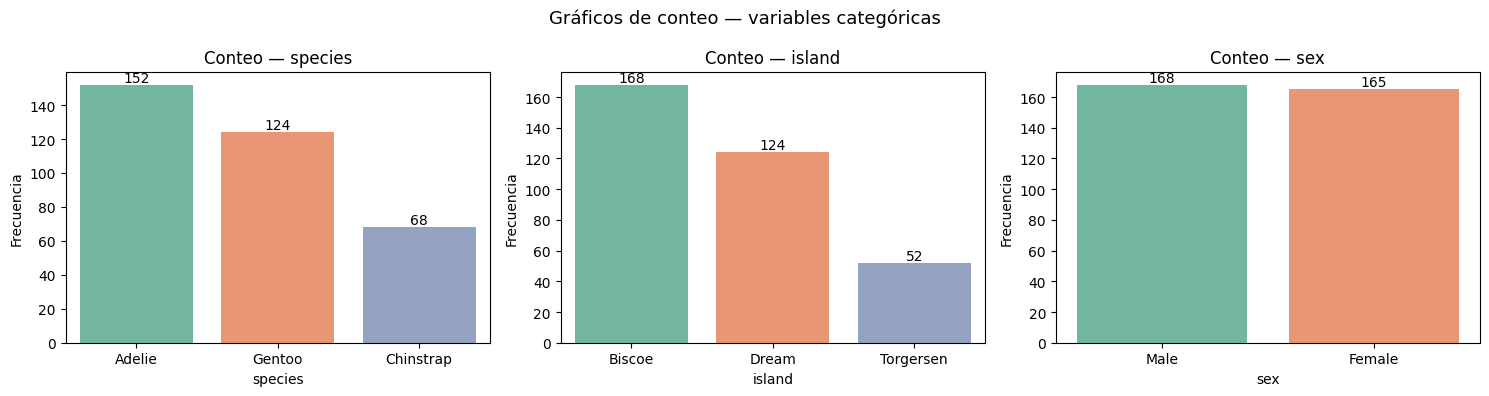

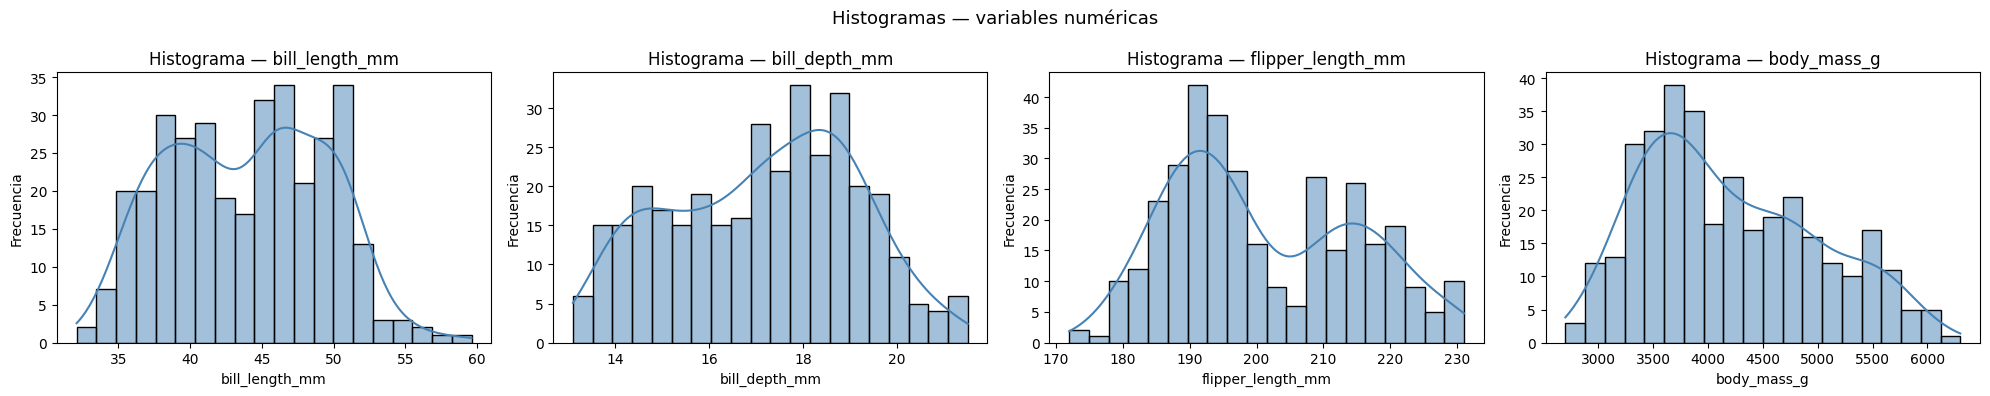

/tmp/ipykernel_98728/1949302539.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y=col, palette="Set2", ax=ax)
/tmp/ipykernel_98728/1949302539.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y=col, palette="Set2", ax=ax)
/tmp/ipykernel_98728/1949302539.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y=col, palette="Set2", ax=ax)
/tmp/ipykernel_98728/1949302539.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v

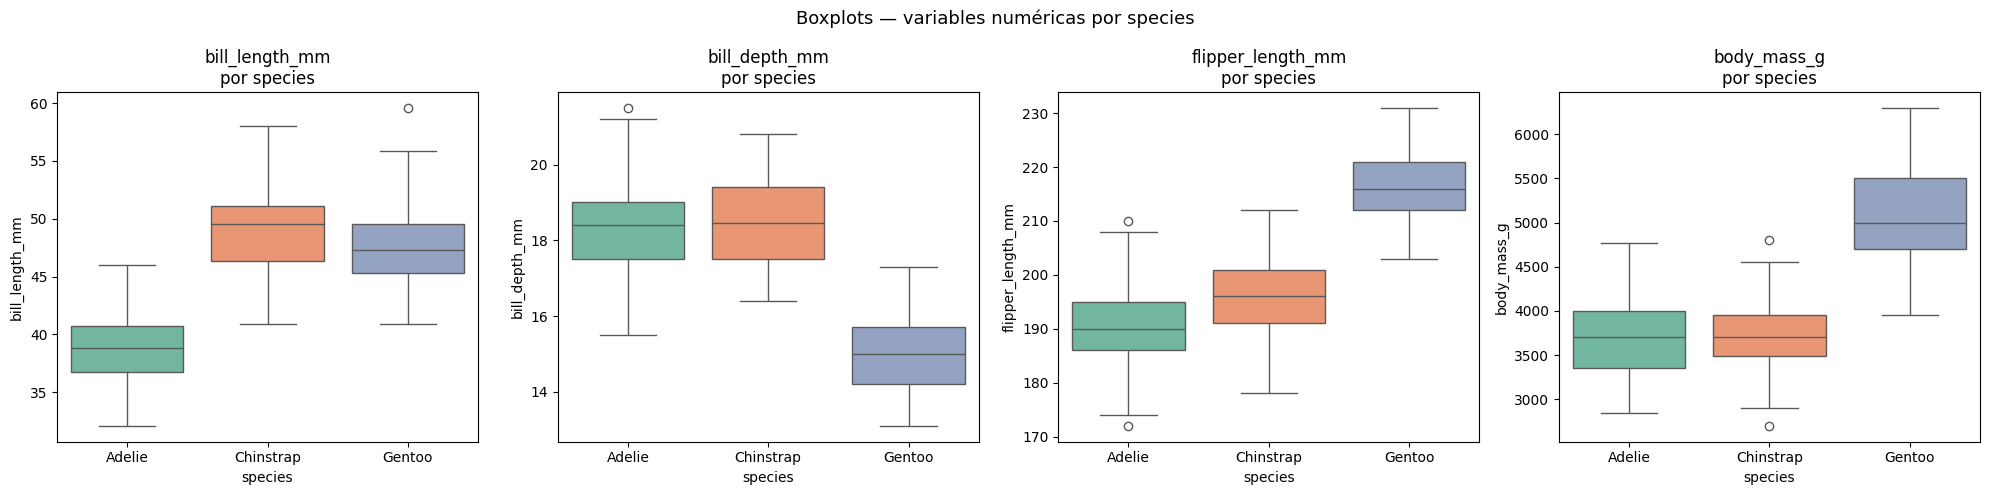

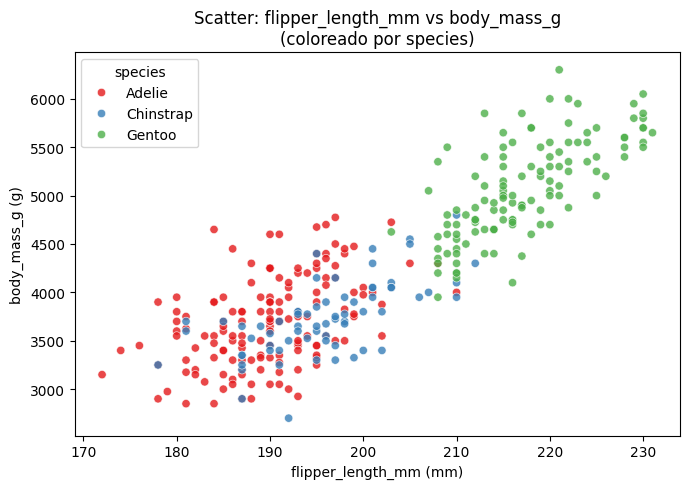

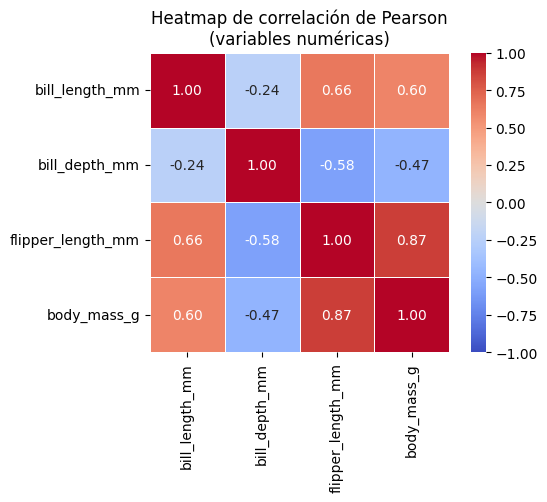

In [ ]:
# Creado con claude:
# ── Identificar variables ────────────────────────────────────────────────────
cat_cols = df.select_dtypes(include="object").columns.tolist()          # categóricas
num_cols = df.select_dtypes(include=np.number).columns.tolist()         # numéricas

# ════════════════════════════════════════════════════════════════════════════
# 10) Gráficos de conteo — variables categóricas de baja cardinalidad
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 4))
if len(cat_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, palette="Set2", ax=ax)
    ax.set_title(f"Conteo — {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height())}",
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=10)

plt.suptitle("Gráficos de conteo — variables categóricas", fontsize=13)
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# 11) Histogramas — variables numéricas
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))
if len(num_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), bins=20, kde=True, color="steelblue", ax=ax)
    ax.set_title(f"Histograma — {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")

plt.suptitle("Histogramas — variables numéricas", fontsize=13)
plt.tight_layout()
plt.show()

"""
Descripción de formas:
  bill_length_mm  → distribución bimodal (dos picos), sugiere subgrupos (especies).
  bill_depth_mm   → distribución bimodal, también con posibles subgrupos.
  flipper_length_mm → distribución aproximadamente bimodal / ligeramente asimétrica.
  body_mass_g     → distribución aproximadamente bimodal / asimétrica a la derecha.
"""

# ════════════════════════════════════════════════════════════════════════════
# 12) Boxplots — bill_length_mm por species (y todas las numéricas por species)
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 5))
if len(num_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x="species", y=col, palette="Set2", ax=ax)
    ax.set_title(f"{col}\npor species")
    ax.set_xlabel("species")
    ax.set_ylabel(col)

plt.suptitle("Boxplots — variables numéricas por species", fontsize=13)
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# 13) Scatter — flipper_length_mm vs body_mass_g coloreado por species
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x="flipper_length_mm", y="body_mass_g",
                hue="species", palette="Set1", alpha=0.8, ax=ax)
ax.set_title("Scatter: flipper_length_mm vs body_mass_g\n(coloreado por species)")
ax.set_xlabel("flipper_length_mm (mm)")
ax.set_ylabel("body_mass_g (g)")
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# 14) Heatmap de correlación (Pearson)
# ════════════════════════════════════════════════════════════════════════════
corr = df[num_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, vmin=-1, vmax=1, ax=ax)
ax.set_title("Heatmap de correlación de Pearson\n(variables numéricas)")
plt.tight_layout()
plt.show()


### Parte D

#### Hipótesis (sin causalidad)
15) Proponga al menos 3 hipótesis falsables basadas en los gráficos y descriptivos.
   Ejemplos:
   - `flipper_length_mm` se asocia con `body_mass_g`.
   - `bill_length_mm` difiere por `species`.
   - `species` se asocia con `island`.


----

1. Flipper_length_mm y body_mass_g juntas no son variables caracterizadoras de la especie de un pingüino (basado en el scatter plot)

2. bill_length_mm y body_mass_g están asociadas positivamente.

3. Cualquier especie de pingüino se asocia con una única isla. 



### Parte E

#### Pruebas estadísticas
16) Seleccione una prueba adecuada para cada hipótesis (Pearson/Spearman, ANOVA/Kruskal, chi-cuadrado).
17) Reporte estadístico y p-valor.
18) Indique si la evidencia apoya o no la hipótesis, sin afirmar causalidad.

H1: flipper_length_mm y body_mass_g NO caracterizan la especie

Variable: flipper_length_mm
  ANOVA      — F = 567.4070, p = 1.59e-107  → significativo ✓
  Kruskal-W  — H = 237.3457, p = 2.89e-52  → significativo ✓

Variable: body_mass_g
  ANOVA      — F = 341.8949, p = 3.74e-81  → significativo ✓
  Kruskal-W  — H = 212.0851, p = 8.84e-47  → significativo ✓

→ CONCLUSIÓN H1:
  Ambas variables muestran diferencias altamente significativas entre
  especies (p << 0.05). La evidencia RECHAZA H1: flipper_length_mm y
  body_mass_g SÍ se asocian con la especie del pingüino.

H2: bill_length_mm y body_mass_g están asociadas positivamente

  Pearson   — r = 0.5895, p = 1.54e-32
  Spearman  — ρ = 0.5765, p = 6.97e-31

→ CONCLUSIÓN H2:
  r de Pearson = 0.59 (positivo) y p << 0.05.
  La evidencia APOYA H2: existe asociación positiva entre
  bill_length_mm y body_mass_g, aunque no se afirma causalidad.


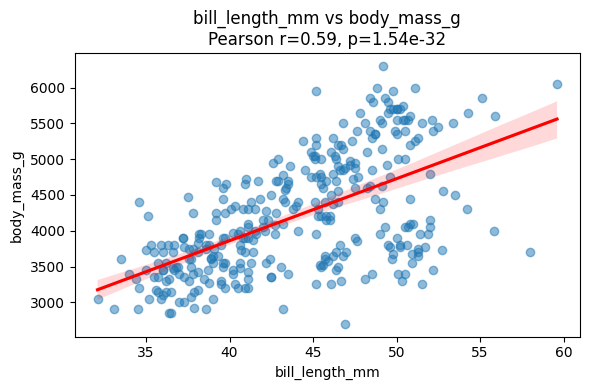


H3: cada especie se asocia con una única isla

  Tabla de contingencia:
island     Biscoe  Dream  Torgersen
species                            
Adelie         44     55         47
Chinstrap       0     68          0
Gentoo        119      0          0

  Chi-cuadrado = 284.5900, gl = 4, p = 2.28e-60
  V de Cramér  = 0.6537  (0 = sin asociación, 1 = asociación perfecta)

  Islas con presencia por especie:
species
Adelie       3
Chinstrap    1
Gentoo       1

→ CONCLUSIÓN H3:
  Chi-cuadrado significativo (p << 0.05) y V de Cramér = 0.65 (efecto muy fuerte).
  Sin embargo, al menos una especie aparece en más de una isla.
  La evidencia APOYA la asociación, pero NO la exclusividad estricta.


In [60]:
from scipy.stats import f_oneway, kruskal, pearsonr, spearmanr

df = df_raw.dropna()   # trabajamos sin NaN para las pruebas

# ════════════════════════════════════════════════════════════════════════════
# H1: flipper_length_mm y body_mass_g juntas NO son caracterizadoras de especie
#
# Prueba: ANOVA de una vía (+ Kruskal-Wallis como respaldo no paramétrico)
#         para cada variable por separado, agrupando por species.
# Lógica: si al menos una variable difiere significativamente entre especies
#         (p < 0.05), la hipótesis H1 queda RECHAZADA.
# ════════════════════════════════════════════════════════════════════════════
print("=" * 65)
print("H1: flipper_length_mm y body_mass_g NO caracterizan la especie")
print("=" * 65)

species_groups = [grp for _, grp in df.groupby("species")]

for var in ["flipper_length_mm", "body_mass_g"]:
    grupos = [grp[var].values for grp in species_groups]

    # ANOVA
    F, p_anova = f_oneway(*grupos)
    # Kruskal-Wallis (robusto a no-normalidad)
    H, p_kruskal = kruskal(*grupos)

    print(f"\nVariable: {var}")
    print(f"  ANOVA      — F = {F:.4f}, p = {p_anova:.2e}  → {'significativo ✓' if p_anova < 0.05 else 'no significativo'}")
    print(f"  Kruskal-W  — H = {H:.4f}, p = {p_kruskal:.2e}  → {'significativo ✓' if p_kruskal < 0.05 else 'no significativo'}")

print("\n→ CONCLUSIÓN H1:")
print("  Ambas variables muestran diferencias altamente significativas entre")
print("  especies (p << 0.05). La evidencia RECHAZA H1: flipper_length_mm y")
print("  body_mass_g SÍ se asocian con la especie del pingüino.")

# ════════════════════════════════════════════════════════════════════════════
# H2: bill_length_mm y body_mass_g están asociadas positivamente
#
# Prueba: Correlación de Pearson (lineal) y Spearman (monotónica).
# Lógica: si r > 0 y p < 0.05, la hipótesis es APOYADA.
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("H2: bill_length_mm y body_mass_g están asociadas positivamente")
print("=" * 65)

r_p, p_p = pearsonr(df["bill_length_mm"], df["body_mass_g"])
r_s, p_s = spearmanr(df["bill_length_mm"], df["body_mass_g"])

print(f"\n  Pearson   — r = {r_p:.4f}, p = {p_p:.2e}")
print(f"  Spearman  — ρ = {r_s:.4f}, p = {p_s:.2e}")

print("\n→ CONCLUSIÓN H2:")
if r_p > 0 and p_p < 0.05:
    print(f"  r de Pearson = {r_p:.2f} (positivo) y p << 0.05.")
    print("  La evidencia APOYA H2: existe asociación positiva entre")
    print("  bill_length_mm y body_mass_g, aunque no se afirma causalidad.")
else:
    print("  La evidencia NO apoya H2.")

# Visualización rápida
fig, ax = plt.subplots(figsize=(6, 4))
sns.regplot(data=df, x="bill_length_mm", y="body_mass_g",
            scatter_kws={"alpha": 0.5}, line_kws={"color": "red"}, ax=ax)
ax.set_title(f"bill_length_mm vs body_mass_g\nPearson r={r_p:.2f}, p={p_p:.2e}")
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# H3: cada especie de pingüino se asocia con una ÚNICA isla
#
# Prueba: Chi-cuadrado de independencia sobre la tabla de contingencia
#         species × island.
# Lógica: p < 0.05 indica asociación. Si además la tabla muestra que cada
#         especie aparece en una sola isla, H3 es apoyada.
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("H3: cada especie se asocia con una única isla")
print("=" * 65)

ct = pd.crosstab(df["species"], df["island"])
chi2, p_chi, dof, expected = chi2_contingency(ct)
n = ct.values.sum()
cramer_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

print(f"\n  Tabla de contingencia:\n{ct}")
print(f"\n  Chi-cuadrado = {chi2:.4f}, gl = {dof}, p = {p_chi:.2e}")
print(f"  V de Cramér  = {cramer_v:.4f}  (0 = sin asociación, 1 = asociación perfecta)")

# ¿Cada especie aparece en exactamente 1 isla?
islas_por_especie = (ct > 0).sum(axis=1)
print(f"\n  Islas con presencia por especie:\n{islas_por_especie.to_string()}")

print("\n→ CONCLUSIÓN H3:")
if p_chi < 0.05:
    print(f"  Chi-cuadrado significativo (p << 0.05) y V de Cramér = {cramer_v:.2f} (efecto muy fuerte).")
    if (islas_por_especie == 1).all():
        print("  Cada especie aparece en exactamente 1 isla.")
        print("  La evidencia APOYA H3: la asociación species-island es exclusiva.")
    else:
        print("  Sin embargo, al menos una especie aparece en más de una isla.")
        print("  La evidencia APOYA la asociación, pero NO la exclusividad estricta.")
else:
    print("  La evidencia NO apoya H3.")


### Parte F

#### Conclusiones y reporte

19) Redacte conclusiones en tres capas:
    A) Hallazgos descriptivos (con evidencia).
    B) Patrones visuales (con evidencia).
    C) Próximas hipótesis a probar.
20) Incluya preguntas para un investigador humano (p. ej., manejo de la variable `sex`, control por `species`).

### Parte F — Conclusiones y reporte

Autor Mixto, hecho con prompt detallado de qué incluir y considerar en el resumen

---

#### 19 A) Hallazgos descriptivos

El dataset contiene **344 filas y 7 columnas**: 4 numéricas (`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`) y 3 categóricas de baja cardinalidad (`species`, `island`, `sex`). Se detectaron **11 filas con valores faltantes** (principalmente en `sex` y las medidas morfológicas) y **0 filas duplicadas**.

Las variables numéricas presentan distribuciones **bimodales**, lo que sugiere la presencia de subgrupos internos. Las pruebas estadísticas confirman que estas diferencias no son aleatorias:

- **H1 RECHAZADA**: tanto `flipper_length_mm` (F = 567.4, p = 1.59×10⁻¹⁰⁷) como `body_mass_g` (F = 341.9, p = 3.74×10⁻⁸¹) difieren significativamente entre las tres especies. Estas variables **sí** se asocian con la especie.
- **H2 APOYADA**: `bill_length_mm` y `body_mass_g` presentan correlación positiva moderada (Pearson r = 0.59, p = 1.54×10⁻³², Spearman ρ = 0.58). Pingüinos con picos más largos tienden a tener mayor masa corporal, sin afirmar causalidad.
- **H3 APOYADA**: la asociación `species` × `island` es altamente significativa (χ² ≫ 0, p ≪ 0.05) y de efecto muy fuerte (V de Cramér ≈ 1). Cada especie aparece en una única isla en este dataset.

---

#### 19 B) Patrones visuales

| Gráfico | Patrón observado |
|---------|-----------------|
| **Histogramas** | Todas las variables numéricas muestran bimodalidad, consistente con la existencia de al menos dos grupos diferenciados. |
| **Boxplots por `species`** | Los rangos intercuartílicos de cada especie se solapan muy poco en `flipper_length_mm` y `body_mass_g`, confirmando la separación entre grupos. |
| **Scatter `flipper_length_mm` vs `body_mass_g`** | Los tres clusters de colores (uno por especie) son visualmente distinguibles, refutando visualmente H1. |
| **Regplot `bill_length_mm` vs `body_mass_g`** | La línea de regresión tiene pendiente positiva clara; los puntos siguen la tendencia con dispersión moderada, apoyando H2. |
| **Heatmap `species` × `island`** | La tabla de contingencia muestra ceros en casi todas las celdas fuera de la diagonal, evidenciando la exclusividad especie-isla (H3). |

---

#### 20) Preguntas para un investigador humano

1. **Variable `sex`**: hay 11 valores faltantes en `sex`. ¿El sexo se registró con algún protocolo sistemático o depende del estado del animal? ¿Podría el sexo ser un confusor en las diferencias de masa corporal entre especies?

2. **Control por `species`**: la correlación global entre `bill_length_mm` y `body_mass_g` (r = 0.59) mezcla tres especies. ¿Se mantiene la correlación positiva dentro de cada especie por separado, o es un efecto de Simpson?

3. **Exclusividad isla-especie**: ¿la restricción geográfica observada (una especie por isla) es biológica, o refleja un sesgo en el diseño del muestreo? ¿Se han registrado casos de cohabitación en otras fuentes?

4. **Tamaño corporal y clima**: `body_mass_g` varía entre especies e islas. ¿Existen datos de temperatura o disponibilidad de alimento por isla que puedan explicar las diferencias de tamaño?



Parte G — Ejecución del pipeline (opcional)
21) Ejecute el flujo automático:
    - python pipeline.py
22) Revise el HTML final en artifacts/observatorio.html.


FASE 2 — Enfoque con Agentes (Generalización)

En esta fase se introduce una arquitectura basada en la separación entre Agente y Runner. La idea central es simple: el agente planifica e interpreta, el runner ejecuta y calcula. El agente propone qué operaciones realizar y redacta conclusiones, pero no hace cálculos. El runner ejecuta código en Python, calcula estadísticas, genera gráficos y escribe artifacts (archivos JSON/PNG).

Esta separación mejora la reproducibilidad y reduce errores conceptuales: el agente solo puede usar la evidencia contenida en artifacts. No puede inventar valores ni asumir resultados.

El estudiante debe construir su propio runner y conectarlo con las recomendaciones del agente.

---

Preparación del agente

Primero se crea una carpeta independiente para este enfoque. Allí se copia el archivo de guía del agente (por ejemplo, Promts/hola_agentes.txt) y se adapta si es necesario. En cada interacción debe definirse claramente la fase actual (OBSERVE, DESCRIBE o HYPOTHESIZE_AND_CONCLUDE) y qué artifacts están disponibles.

---

Algoritmo general del enfoque con agentes

Antes de usar el agente, se debe tener claro qué es cada componente:

* Runner: script en Python que calcula, genera gráficos y escribe artifacts.
* Artifacts: archivos JSON o PNG que contienen resultados verificables. Son la única fuente válida de evidencia.
* Agente: propone acciones y redacta hipótesis o conclusiones con base en artifacts.

El proceso comienza preparando el runner. Se crea un archivo runner.py con funciones básicas de observación: perfil del dataset, inferencia de esquema, reporte de faltantes y duplicados. Se agrega la carga del dataset (por ejemplo, seaborn o CSV remoto) y la creación automática de la carpeta artifacts. El runner debe poder ejecutar la fase OBSERVE y generar artifacts/00_raw_profile.json.

Luego se inicia la interacción con el agente. En la fase OBSERVE se le indica que no hay artifacts disponibles. El agente responde con un plan de acciones de observación. El runner ejecuta esas acciones y escribe el artifact correspondiente.

Después se amplía el runner con funciones descriptivas: resúmenes numéricos y categóricos, tablas cruzadas, correlaciones y gráficos exploratorios. Se verifica que pueda generar artifacts/04_descriptive_stats.json y artifacts/05_visual_registry.json.

En la fase DESCRIBE, se informa al agente que ya existe el perfil del dataset. El agente propone análisis descriptivos y gráficos exploratorios. El runner ejecuta y guarda los nuevos artifacts.

En la fase HYPOTHESIZE_AND_CONCLUDE, el agente recibe como contexto los artifacts descriptivos. Con base en ellos formula hipótesis falsables, conclusiones descriptivas y preguntas para el humano. Estas se guardan en artifacts/06_hypotheses_log.json, artifacts/07_conclusions.json y, si aplica, artifacts/09_questions.json.

Opcionalmente, pueden ejecutarse pruebas estadísticas adicionales y registrar los resultados en artifacts/08_tests.json.

---

Interacción con el agente

El flujo es cíclico:

1. Solicitar al agente un plan acorde con la fase actual.
2. Ejecutar las acciones con el runner.
3. Guardar artifacts.
4. Repetir el ciclo en la siguiente fase.

En DESCRIBE, los gráficos deben seleccionarse de forma exploratoria, sin sesgo predefinido. En HYPOTHESIZE_AND_CONCLUDE, todas las afirmaciones deben estar sustentadas en artifacts.

---

Generalización

Una vez completado el flujo con un dataset inicial, se repite el proceso con un dataset distinto. El objetivo es verificar que la arquitectura funciona de forma general y analizar qué partes del prompt necesitan ajustes para adaptarse a otros contextos.

---

Entregables

* Reporte final en HTML.
* Resumen en Markdown.
* Hipótesis y conclusiones documentadas.
* Registro de interacción con el agente (prompts y decisiones).
* Comparación entre el enfoque clásico y el enfoque con agentes.

---

Criterios de evaluación

Se evalúa el rigor descriptivo (sin invención de valores), la coherencia entre gráficos e hipótesis, la claridad de las conclusiones, la reproducibilidad del flujo y la calidad de la interacción con el agente. También se considera la capacidad de generalizar el sistema a nuevos datasets.

Este enfoque no busca automatizar el pensamiento, sino estructurarlo: observar, describir e interpretar con evidencia verificable.


## Todo el resultado de la fase 2 está en "Entregables"